In [2]:
library(tidyverse)
library(dplyr)
library(cowplot)
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

── Attaching core tidyverse packages ─────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ───────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




In [3]:
# Read file
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-10_fp_tp1_filt_nulliparous.csv", header = TRUE)
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-10_sp_tp1_filt_nulliparous.csv", header = TRUE)
combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-11_combined_tp1_filt_nulliparous.csv", header = TRUE)

In [4]:
#summary(combined)
combined$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "First pregnancy " "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[45] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[49] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"

In [5]:
head(fp_tp1)
dim(fp_tp1)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
2,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0
3,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
4,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
5,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
6,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,0,NA,NA,NA,NA,38,Induction,NA,NA,0


[1]  26 566

In [6]:
head(sp_tp1)
dim(sp_tp1)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
2,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,41,Induction,NA,NA,0
3,5309,S0e78496,NA,0,0,0,2020-12-17,P1f95844,0,33,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
4,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
5,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
6,5415,S424fd61,NA,0,0,0,2020-11-03,P424fd61,0,40,⋯,31,NA,NA,NA,NA,38,Spontaneous,NA,NA,0


[1]  26 566

In [7]:
head(combined)
dim(combined)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
3,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
4,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
5,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
6,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy


[1]  52 567

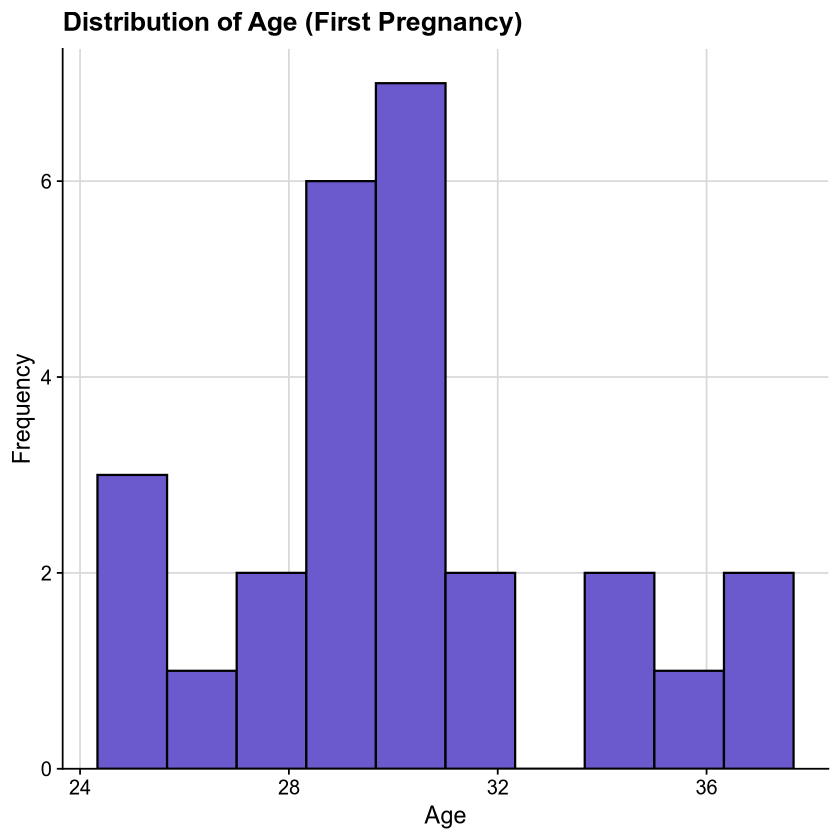

In [8]:
#===============================================================================
# Histogram for the age distribution (remove NA values)
# First Pregnancy 
fp_tp1_plot <- fp_tp1 |> 
  ggplot(aes(x = age_checked)) + 
  geom_histogram(bins = 10, fill = "slateblue", color = "black", na.rm = TRUE) +
  labs(
    title = "Distribution of Age (First Pregnancy)",
    x = "Age",
    y = "Frequency"
  ) +
  scale_y_continuous(
    # don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  )
  fp_tp1_plot + theme_half_open() +
  background_grid()

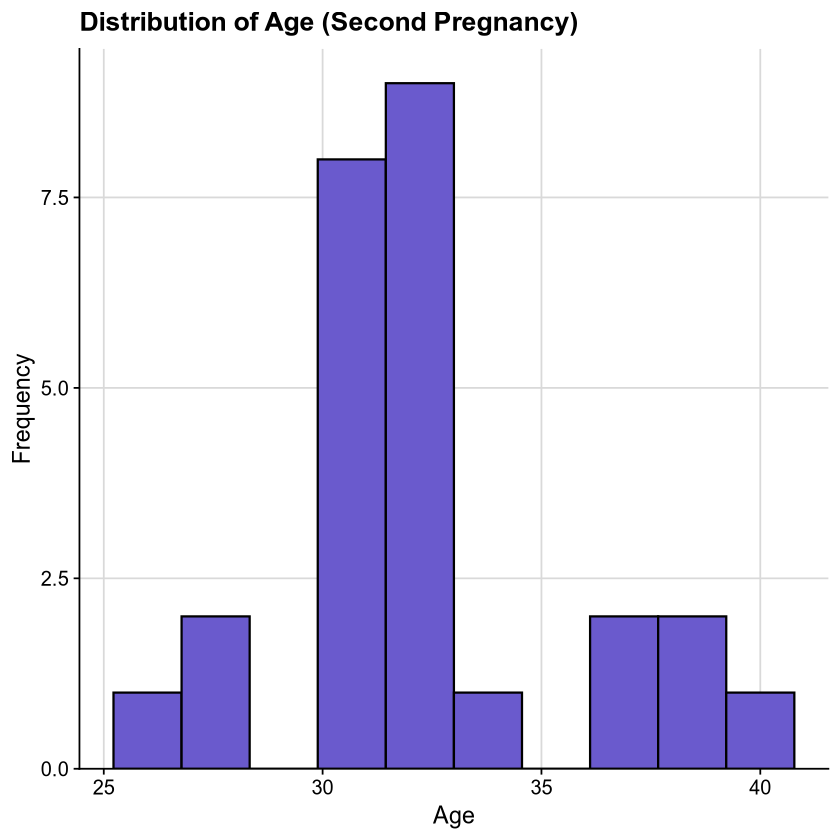

In [9]:
  
#Second Pregnancy
sp_tp1_plot <- sp_tp1 |> 
  ggplot(aes(x = age_checked)) +
  geom_histogram(bins = 10, fill = "slateblue", color = "black", na.rm = TRUE) +
  labs(
    title = "Distribution of Age (Second Pregnancy)",
    x = "Age",
    y = "Frequency"
  ) +
  scale_y_continuous(
    # don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  )
sp_tp1_plot + theme_half_open() +
  background_grid()

In [10]:
# Checking for NA ages
fp_tp1 |> filter(is.na(fp_tp1$age_checked)) |> pull(Q1_Personnummer)
sp_tp1 |> filter(is.na(fp_tp1$age_checked)) |> pull(Q1_Personnummer)

character(0)

character(0)

In [11]:
# Perform Shapiro-Wilk test for First Pregnancy --> we can trust the shapiro test since our sample size isnt so large
shapiro_first <- shapiro.test(fp_tp1$age_checked)
shapiro_first


	Shapiro-Wilk normality test

data:  fp_tp1$age_checked
W = 0.92967, p-value = 0.07611


In [12]:
# Perform Shapiro-Wilk test for Second Pregnancy
shapiro_second <- shapiro.test(sp_tp1$age_checked)
shapiro_second


	Shapiro-Wilk normality test

data:  sp_tp1$age_checked
W = 0.93756, p-value = 0.1175


# Age_checked========================================================================================================================================

In [13]:
Age_summary_stats <- combined|>
  group_by(Group) |>
  summarise(
    mean_age = mean(age_checked, na.rm = TRUE),
    sd_age = sd(age_checked, na.rm = TRUE),
    min_age = min(age_checked, na.rm = TRUE),
    max_age = max(age_checked, na.rm = TRUE)
  )
print(Age_summary_stats)

# A tibble: 2 × 5
  Group              mean_age sd_age min_age max_age
  <chr>                 <dbl>  <dbl>   <int>   <int>
1 "First pregnancy "     30.4   3.41      25      37
2 "Second pregnancy"     32.4   3.52      26      40


In [14]:
# Check NA
combined |> filter(is.na(combined$age_checked)) |> group_by(Group) |> pull(Q1_Personnummer)

character(0)

# BMI_prior========================================================================================================================================

In [15]:
combined$BMI_prior
BMI_summary_stat <- combined |>
  group_by(Group)|> 
  summarise(
    mean_bmi = mean(BMI_prior, na.rm = TRUE),
    sd_bmi = sd(BMI_prior, na.rm = TRUE),
    min_bmi = min(BMI_prior, na.rm = TRUE),
    max_bmi = max(BMI_prior, na.rm = TRUE)
  )
print(BMI_summary_stat)

[1] 21 25 22 21 21 24 21 28 19 21 20 16 24 27 29 22 23 23 19 24 23 29 23 23 23
[26] 23 25 25 21 22 23 23 23 29 19 20 21 17 33 26 29 24 28 23 19 26 23 30 23 23
[51] 21 23

# A tibble: 2 × 5
  Group              mean_bmi sd_bmi min_bmi max_bmi
  <chr>                 <dbl>  <dbl>   <int>   <int>
1 "First pregnancy "     22.8   3.04      16      29
2 "Second pregnancy"     23.8   3.72      17      33


# BMI categories -------------------------------------------------------------

In [16]:
# BMI_groups
grep("BMI", names(combined), value = TRUE)
combined$BMI_3_groups
# check type of data
class(combined$BMI_now_3_groups)

[1] "BMI_prior"        "BMI_3_groups"     "BMI_now_3_groups"

[1] "18.5-25 Normal weight" "Missing"               "18.5-25 Normal weight"
 [4] "18.5-25 Normal weight" "18.5-25 Normal weight" "18.5-25 Normal weight"
 [7] "18.5-25 Normal weight" "> 25 Overweight"       "18.5-25 Normal weight"
[10] "18.5-25 Normal weight" "18.5-25 Normal weight" "< 18.5 Underweight"   
[13] "18.5-25 Normal weight" "> 25 Overweight"       "> 25 Overweight"      
[16] "18.5-25 Normal weight" "18.5-25 Normal weight" "18.5-25 Normal weight"
[19] "18.5-25 Normal weight" "18.5-25 Normal weight" "18.5-25 Normal weight"
[22] "> 25 Overweight"       "18.5-25 Normal weight" "18.5-25 Normal weight"
[25] "18.5-25 Normal weight" "18.5-25 Normal weight" "Missing"              
[28] "Missing"               "18.5-25 Normal weight" "18.5-25 Normal weight"
[31] "18.5-25 Normal weight" "18.5-25 Normal weight" "18.5-25 Normal weight"
[34] "> 25 Overweight"       "18.5-25 Normal weight" "18.5-25 Normal weight"
[37] "18.5-25 Normal weight" "< 18.5 Underweight"    "> 25 Overweight"      
[40] "> 25 Overweight"       "> 25 Overweight"       "18.5-25 Normal weight"
[43] "> 25 Overweight"       "18.5-25 Normal weight" "18.5-25 Normal weight"
[46] "> 25 Overweight"       "18.5-25 Normal weight" "> 25 Overweight"      
[49] "18.5-25 Normal weight" "18.5-25 Normal weight" "18.5-25 Normal weight"
[52] "18.5-25 Normal weight"

[1] "character"

In [17]:
# Count total in both groups
total_counts_bmi <- table(combined$Group)
print(total_counts_bmi)


First pregnancy  Second pregnancy 
              26               26 


In [53]:
meta_BMI_update <- combined %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update$BMI_group_prior)

[1] "Normalweight" "Overweight"   "Normalweight" "Normalweight" "Normalweight"
[6] "Normalweight"

In [54]:
# Calculate the count and percentage for each BMI_3_groups within each group
BMI_3_groups_summary <- combined |>
  group_by(Group, BMI_group_prior) |>         
  summarise(
    count = n(),
    
    .groups = 'drop'  # This argument drops the grouping after summarising                    
  ) |>
  group_by(Group) |> # Regroup by 'group' to calculate percentage
  mutate(
    percentage = (count / sum(count)) * 100  
  )
print(BMI_3_groups_summary)

ERROR: [1m[33mError[39m in `group_by()`:[22m
[1m[22m[33m![39m Must group by variables found in `.data`.
[31m✖[39m Column `BMI_group_prior` is not found.


# Excess weight========================================================================================================================================

In [19]:
grep("excess",names(combined), value = TRUE )
class(combined$excess_weight)
table(combined$excess_weight)

combined$excess_weight <- as.factor(combined$excess_weight)
total_counts_excess_weight <- table(combined$Group)

[1] "excess_weight"

[1] "character"


 No Yes 
 28  22 

In [20]:
# Generate a table
summary_excess_weight <- combined |>
  group_by(Group, excess_weight) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(summary_excess_weight)

# A tibble: 6 × 4
# Groups:   Group [2]
  Group              excess_weight count percentage
  <chr>              <fct>         <int>      <dbl>
1 "First pregnancy " No               17      65.4 
2 "First pregnancy " Yes               8      30.8 
3 "First pregnancy " NA                1       3.85
4 "Second pregnancy" No               11      42.3 
5 "Second pregnancy" Yes              14      53.8 
6 "Second pregnancy" NA                1       3.85


# Gestational diabetes========================================================================================================================================

In [21]:
grep("diabetes", names(combined), value = TRUE)
table(combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes)

[1] "Q1_X73.1_Pregnancy_problems_gestational_diabetes"
[2] "Q1_prior_diabetes_medication"                    
[3] "Q1_during_diabetes_medication"                   
[4] "Q2_X13.1.Pregproblem_gestational_diabetes"       
[5] "Q2_diabetes_medication"                          
[6] "Q3_X41_Pregproblem_gestational_diabetes"         
[7] "Q3_diabetes_medication"


Nej 
  6 

In [22]:
class(combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes)
combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes <- as.factor(combined$Q1_X73.1_Pregnancy_problems_gestational_diabetes)

[1] "character"

In [23]:
summary_diabetes <- combined |>
  group_by(Group, Q1_X73.1_Pregnancy_problems_gestational_diabetes) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(summary_diabetes)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q1_X73.1_Pregnancy_problems_gestational_…¹ count percentage
  <chr>              <fct>                                      <int>      <dbl>
1 "First pregnancy " Nej                                            3       11.5
2 "First pregnancy " NA                                            23       88.5
3 "Second pregnancy" Nej                                            3       11.5
4 "Second pregnancy" NA                                            23       88.5
# ℹ abbreviated name: ¹​Q1_X73.1_Pregnancy_problems_gestational_diabetes


# Depression========================================================================================================================================

In [24]:
grep("depression", names(combined), value= TRUE)
grep("Depression", names(combined), value= TRUE)
combined$Depression_score_sum_Q1
class(combined$Depression_score_sum_Q1)

[1] "Q1_X73.7_Pregnancy_problems_depression"
[2] "Q2_X13.7.Pregproblem_depression"       
[3] "Q3_X41_Pregproblem_depression"

[1] "Depression_score_sum_Q1" "Depression_score_sum_Q2"
[3] "Depression_score_sum_Q3"

[1]  6  2 NA NA  3  0  0  4  1  0  1  1  6 18  9 11  8 NA  4  3  2 11 13  2  2
[26]  8  0 10  9 14 15  3  2  4  2 NA  4  0  2  7 15  9 16  5  1 18  7 11  8  6
[51]  3  9

[1] "integer"

In [25]:
# Convert to categories
depression_category <- ifelse(combined$Depression_score_sum_Q1 >= 0 & combined$Depression_score_sum_Q1 < 13,  "no depression", 
                              ifelse(combined$Depression_score_sum_Q1 >= 13 & combined$Depression_score_sum_Q1 <= 30, "depression", NA))
depression_category
sum(is.na(depression_category))

[1] "no depression" "no depression" NA              NA             
 [5] "no depression" "no depression" "no depression" "no depression"
 [9] "no depression" "no depression" "no depression" "no depression"
[13] "no depression" "depression"    "no depression" "no depression"
[17] "no depression" NA              "no depression" "no depression"
[21] "no depression" "no depression" "depression"    "no depression"
[25] "no depression" "no depression" "no depression" "no depression"
[29] "no depression" "depression"    "depression"    "no depression"
[33] "no depression" "no depression" "no depression" NA             
[37] "no depression" "no depression" "no depression" "no depression"
[41] "depression"    "no depression" "depression"    "no depression"
[45] "no depression" "depression"    "no depression" "no depression"
[49] "no depression" "no depression" "no depression" "no depression"

[1] 4

In [26]:
combined$Q1_Depression_category <- depression_category
table(combined$Q1_Depression_category)


   depression no depression 
            7            41 

In [27]:
Q1_summary_depression <- combined |>
  group_by(Group, Q1_Depression_category) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(Q1_summary_depression)

# A tibble: 6 × 4
# Groups:   Group [2]
  Group              Q1_Depression_category count percentage
  <chr>              <chr>                  <int>      <dbl>
1 "First pregnancy " depression                 2       7.69
2 "First pregnancy " no depression             21      80.8 
3 "First pregnancy " NA                         3      11.5 
4 "Second pregnancy" depression                 5      19.2 
5 "Second pregnancy" no depression             20      76.9 
6 "Second pregnancy" NA                         1       3.85


# Stress================================================================================================================================================================================================================

In [28]:
combined$high_stress_Q1
table(combined$high_stress_Q1)

[1] 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 0
[39] 1 0 1 1 1 1 0 1 0 1 0 0 0 1


 0  1 
35 17 

In [29]:
summary_stress <- combined |>
  group_by(Group, high_stress_Q1) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  )
print(summary_stress)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              high_stress_Q1 count percentage
  <chr>                       <int> <int>      <dbl>
1 "First pregnancy "              0    21       80.8
2 "First pregnancy "              1     5       19.2
3 "Second pregnancy"              0    14       53.8
4 "Second pregnancy"              1    12       46.2


# Smoking===============================================================================================================================================================================================================

In [30]:
grep("smok", names(combined), value = TRUE)
grep("Smok", names(combined), value = TRUE)

[1] "Q1_X55_Year_stopped_smoking"       "Q1_X57_Which_other_smoking_habits"
[3] "smoking"

[1] "Q1_Smoking_checked"                  
[2] "Q2_X25_Smoking_snus_now"             
[3] "Q3_X35_Smoking_snus_end_of_pregnancy"

In [31]:
combined$Q1_Smoking_checked

[1] "Nej, jag har aldrig rökt" "Rökt tidigare"           
 [3] "Feströkare"               "Rökt tidigare"           
 [5] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
 [7] "Rökt tidigare"            "Nej, jag har aldrig rökt"
 [9] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[11] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[13] "Rökt tidigare"            "Rökt tidigare"           
[15] "Rökt tidigare"            "Feströkare"              
[17] "Nej, jag har aldrig rökt" "Rökt tidigare"           
[19] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[21] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[23] "Rökt tidigare"            "Nej, jag har aldrig rökt"
[25] "Nej, jag har aldrig rökt" "Rökt tidigare"           
[27] "Nej, jag har aldrig rökt" "Rökt tidigare"           
[29] "Feströkare"               "Rökt tidigare"           
[31] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[33] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[35] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[37] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[39] "Rökt tidigare"            "Rökt tidigare"           
[41] "Rökt tidigare"            "Rökt tidigare"           
[43] "Nej, jag har aldrig rökt" "Rökt tidigare"           
[45] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[47] "Nej, jag har aldrig rökt" "Nej, jag har aldrig rökt"
[49] "Rökt tidigare"            "Nej, jag har aldrig rökt"
[51] "Nej, jag har aldrig rökt" "Rökt tidigare"

In [32]:
# Convert Q1_Smoking_ to categorieschecked
smoking_category <- ifelse(combined$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                           ifelse(combined$Q1_Smoking_checked == "Rökt tidigare", 0,
                              ifelse(combined$Q1_Smoking_checked == "Feströkare", 1, NA)))
table(smoking_category)
# Check for NA
sum(is.na(smoking_category))

smoking_category
 0  1 
49  3 

[1] 0

In [33]:
# Create new column with smoking category
combined$smoking_category_Q1 <- smoking_category
combined$smoking_category_Q1

summary_smoking <- combined |>
  group_by(Group, smoking_category_Q1) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count / sum(count)) * 100
  ) 
print(summary_smoking)

[1] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              smoking_category_Q1 count percentage
  <chr>                            <dbl> <int>      <dbl>
1 "First pregnancy "                   0    24      92.3 
2 "First pregnancy "                   1     2       7.69
3 "Second pregnancy"                   0    25      96.2 
4 "Second pregnancy"                   1     1       3.85


# Alcohol===============================================================================================================================================================================================================

In [34]:
grep("Alcohol", names(combined), value = TRUE)
combined$Q1_X64_Alcohol_during_pregnancy
class(combined$Q1_X64_Alcohol_during_pregnancy)

[1] "Q1_X62_Alcohol_3_months_before_pregnancy"    
[2] "Q1_X64_Alcohol_during_pregnancy"             
[3] "Q1_X62_Alcohol_3_months_before_pregnancy_cat"
[4] "Q1_X64_Alcohol_during_pregnancy_cat"

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

[1] "integer"

In [35]:
summary_alcohol <- combined |>
  group_by(Group, Q1_X64_Alcohol_during_pregnancy) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_alcohol)

# A tibble: 3 × 4
# Groups:   Group [2]
  Group              Q1_X64_Alcohol_during_pregnancy count percentage
  <chr>                                        <int> <int>      <dbl>
1 "First pregnancy "                               0    25      96.2 
2 "First pregnancy "                               1     1       3.85
3 "Second pregnancy"                               0    26     100   


# Antibiotic================================================================================================================================================================================================================================================================================

In [36]:
combined$Q1_X43.Antibiotics_last_3_months

Q1_summary_antibiotics <- combined %>%
  group_by(Group) %>%
  summarise(
    yes_count = sum(Q1_X43.Antibiotics_last_3_months == 1, na.rm = TRUE),  # counts only "yes"
    total = n(), # Total in each group
    percent_yes = (yes_count / total) * 100   # Percentage
  )

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [37]:
Q1_summary_antibiotics
# Check NA - do I need this in this case?
combined |> 
  filter(is.na(combined$Q1_X43.Antibiotics_last_3_months)) |> 
  group_by(Group) |> pull(Q1_Personnummer)

Group,yes_count,total,percent_yes
<chr>,<int>,<int>,<dbl>
First pregnancy,1,26,3.846154
Second pregnancy,0,26,0.000000


character(0)

# Diet================================================================================================================================================================================================================================================================================

In [38]:
combined$Q1_dietscore
combined$Q1_healthydiet 
combined$Q1_dailyfiber 

[1] 0 1 0 1 1 2 1 4 1 1 1 2 3 2 2 2 3 2 2 3 1 1 0 1 2 1 1 1 1 4 4 2 0 4 0 0 1 1
[39] 3 2 3 3 3 1 3 3 2 0 1 1 2 3

[1] 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 1
[39] 0 1 0 0 0 1 0 0 1 1 1 1 1 0

[1] 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 1
[39] 1 1 1 0 1 1 1 0 1 1 1 1 1 0

In [39]:
# combined$Q1_healthydiet --> yes if health score less than 3
summary_diet <- combined |>
  group_by(Group, Q1_healthydiet) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/sum(count)) * 100
  )
print(summary_diet)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q1_healthydiet count percentage
  <chr>                       <int> <int>      <dbl>
1 "First pregnancy "              0     4       15.4
2 "First pregnancy "              1    22       84.6
3 "Second pregnancy"              0    10       38.5
4 "Second pregnancy"              1    16       61.5


# Daily fiber================================================================================================================================================================================================================================================================================

In [40]:
combined$Q1_dailyfiber
summary_fiber <-  combined |>
  group_by(Group, Q1_dailyfiber) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/sum(count)) * 100
  )
print(summary_fiber)

[1] 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 1
[39] 1 1 1 0 1 1 1 0 1 1 1 1 1 0

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q1_dailyfiber count percentage
  <chr>                      <int> <int>      <dbl>
1 "First pregnancy "             0     3       11.5
2 "First pregnancy "             1    23       88.5
3 "Second pregnancy"             0     6       23.1
4 "Second pregnancy"             1    20       76.9


# PCOS========================================================================================================================================

In [41]:
combined$Q1_X31_Diagnosed_PCOS

summary_PCOS <- combined |>
  group_by(Group, Q1_X31_Diagnosed_PCOS) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_PCOS)

[1] "Nej"      "Nej"      "Nej"      "Nej"      "Nej"      "Nej"     
 [7] "Nej"      "Nej"      "Ja"       "Nej"      "Nej"      "Nej"     
[13] "Nej"      "Nej"      "Nej"      "Nej"      "Nej"      "Ja"      
[19] "Nej"      "Nej"      "Nej"      "Nej"      "Nej"      "Ja"      
[25] "Vet inte" "Nej"      "Nej"      "Nej"      "Nej"      "Nej"     
[31] "Nej"      "Nej"      "Nej"      "Ja"       "Ja"       "Nej"     
[37] "Nej"      "Nej"      "Nej"      "Nej"      "Nej"      "Nej"     
[43] "Nej"      "Ja"       "Nej"      "Nej"      "Nej"      "Nej"     
[49] "Nej"      "Ja"       "Nej"      "Nej"

# A tibble: 5 × 4
# Groups:   Group [2]
  Group              Q1_X31_Diagnosed_PCOS count percentage
  <chr>              <chr>                 <int>      <dbl>
1 "First pregnancy " Ja                        3      11.5 
2 "First pregnancy " Nej                      22      84.6 
3 "First pregnancy " Vet inte                  1       3.85
4 "Second pregnancy" Ja                        4      15.4 
5 "Second pregnancy" Nej                      22      84.6 


# Diabetes========================================================================================================================================

In [42]:
grep("diabetes", names(combined), value = TRUE)
grep("Diabetes", names(combined), value = TRUE)

[1] "Q1_X73.1_Pregnancy_problems_gestational_diabetes"
[2] "Q1_prior_diabetes_medication"                    
[3] "Q1_during_diabetes_medication"                   
[4] "Q2_X13.1.Pregproblem_gestational_diabetes"       
[5] "Q2_diabetes_medication"                          
[6] "Q3_X41_Pregproblem_gestational_diabetes"         
[7] "Q3_diabetes_medication"

[1] "Gest_Diabetes"

# Preeclampsia============================================================================

In [43]:
grep("preeclampsia", names(combined), value = TRUE)
grep("Preeclampsia", names(combined), value = TRUE)

[1] "Q1_X73.5_Pregnancy_problems_preeclampsia"
[2] "Q2_X13.5.Pregproblem_preeclampsia"       
[3] "preeclampsia_epi_analysis"

character(0)

In [44]:
class(combined$Q1_X73.5_Pregnancy_problems_preeclampsia)
combined$Q1_X73.5_Pregnancy_problems_preeclampsia
combined$Q1_X73.5_Pregnancy_problems_preeclampsia <- as.factor(combined$Q1_X73.5_Pregnancy_problems_preeclampsia)
class(combined$Q1_X73.5_Pregnancy_problems_preeclampsia)
combined$Q1_X73.5_Pregnancy_problems_preeclampsia

[1] "character"

[1] "Nej" NA    NA    "Nej" NA    NA    "Nej" NA    NA    NA    NA    NA   
[13] NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
[25] NA    NA    NA    NA    NA    "Nej" NA    NA    NA    NA    NA    NA   
[37] NA    "Nej" NA    NA    NA    NA    NA    NA    NA    NA    NA    "Nej"
[49] NA    NA    NA    NA

[1] "factor"

[1] Nej  <NA> <NA> Nej  <NA> <NA> Nej  <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[16] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> Nej 
[31] <NA> <NA> <NA> <NA> <NA> <NA> <NA> Nej  <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[46] <NA> <NA> Nej  <NA> <NA> <NA> <NA>
Levels: Nej

In [45]:
summary_preeclampsia <- combined |>
  group_by(Group, Q1_X73.5_Pregnancy_problems_preeclampsia) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_preeclampsia)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q1_X73.5_Pregnancy_problems_preeclampsia count percentage
  <chr>              <fct>                                    <int>      <dbl>
1 "First pregnancy " Nej                                          3       11.5
2 "First pregnancy " NA                                          23       88.5
3 "Second pregnancy" Nej                                          3       11.5
4 "Second pregnancy" NA                                          23       88.5


# Hypertension====================================================================================

In [46]:
grep("pressure", names(combined), value = TRUE)


[1] "Q1_X66.2_prior_treatment_high_bloodpressure"   
 [2] "Q1_X73.4_Pregnancy_problems_high_bloodpressure"
 [3] "Q1_X75_prior_bloodpressure_medication"         
 [4] "Q1_X77_during_bloodpressure_medication"        
 [5] "Q1_prior_bloodpressure"                        
 [6] "Q1_during_bloodpressure"                       
 [7] "Q2_X13.4.Pregproblem_high_bloodpressure"       
 [8] "Q2_X15_during_bloodpressure_medication"        
 [9] "Q2_bloodpressure"                              
[10] "Q3_X42_during_bloodpressure_medication"        
[11] "Q3_bloodpressure"

In [47]:
combined$Q1_X73.4_Pregnancy_problems_high_bloodpressure

[1]  0 NA NA  0 NA NA  0 NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[26] NA NA NA NA  0 NA NA NA NA NA NA NA  0 NA NA NA NA NA NA NA NA NA  0 NA NA
[51] NA NA

In [48]:
combined$Q1_prior_bloodpressure

[1]  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 NA  0  0  0  0
[26]  0  0  0 NA  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
[51]  0  0

In [49]:
combined$Q1_during_bloodpressure

[1]  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 NA  0  0  0  0
[26]  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
[51]  0  0

In [50]:
combined$Q2_X13.4.Pregproblem_high_bloodpressure

[1] "Nej" NA    NA    "Nej" NA    "Nej" NA    NA    NA    NA    NA    NA   
[13] NA    NA    NA    NA    NA    NA    NA    NA    NA    "Nej" NA    NA   
[25] NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    "Nej"
[37] NA    "Nej" NA    NA    NA    NA    NA    NA    NA    NA    NA    NA   
[49] NA    NA    NA    NA

In [51]:
summary_bp <- combined |>
  group_by(Group, Q2_X13.4.Pregproblem_high_bloodpressure) |>
  summarise(
    count = n(),
    
    .groups = 'drop'
  ) |>
  group_by(Group) |>
  mutate(
    percentage = (count/ sum(count)) * 100
  )
print(summary_bp)

# A tibble: 4 × 4
# Groups:   Group [2]
  Group              Q2_X13.4.Pregproblem_high_bloodpressure count percentage
  <chr>              <chr>                                   <int>      <dbl>
1 "First pregnancy " Nej                                         4      15.4 
2 "First pregnancy " NA                                         22      84.6 
3 "Second pregnancy" Nej                                         2       7.69
4 "Second pregnancy" NA                                         24      92.3 
